 📊 GRAFICADOR DE EXAMEN: f(t) y |F(w)|



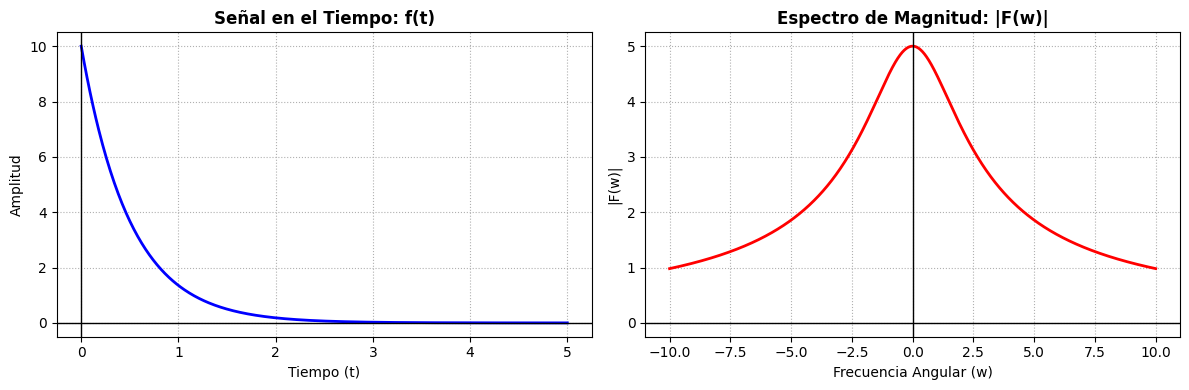

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Configuración matemática
t, w = sp.symbols('t w', real=True)
j = sp.I

def graficar_examen(f_t_expr, F_w_expr):
    print("==================================================")
    print(" 📊 GRAFICADOR DE EXAMEN: f(t) y |F(w)|")
    print("==================================================\n")
    
    # 1. Preparar las funciones (Convertir SymPy a Numpy para graficar rápido)
    # Usamos sp.Abs para sacar la magnitud |F(w)| automáticamente
    f_num = sp.lambdify(t, f_t_expr, 'numpy')
    F_mag_num = sp.lambdify(w, sp.Abs(F_w_expr), 'numpy')
    
    # 2. Crear los vectores de tiempo y frecuencia
    # El tiempo suele graficarse de 0 a un valor positivo (señales causales)
    t_vals = np.linspace(0, 5, 500) 
    # La frecuencia se grafica en un rango simétrico (ej. -10 a 10)
    w_vals = np.linspace(-10, 10, 1000)
    
    # 3. Evaluar
    y_t = np.real(f_num(t_vals))
    y_w = F_mag_num(w_vals)
    
    # 4. Dibujar
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Gráfica en el Tiempo
    ax1.plot(t_vals, y_t, color='blue', linewidth=2)
    ax1.set_title('Señal en el Tiempo: f(t)', fontweight='bold')
    ax1.set_xlabel('Tiempo (t)')
    ax1.set_ylabel('Amplitud')
    ax1.axhline(0, color='black', linewidth=1)
    ax1.axvline(0, color='black', linewidth=1)
    ax1.grid(True, linestyle=':')
    
    # Gráfica en la Frecuencia (Espectro de Magnitud)
    ax2.plot(w_vals, y_w, color='red', linewidth=2)
    ax2.set_title('Espectro de Magnitud: |F(w)|', fontweight='bold')
    ax2.set_xlabel('Frecuencia Angular (w)')
    ax2.set_ylabel('|F(w)|')
    ax2.axhline(0, color='black', linewidth=1)
    ax2.axvline(0, color='black', linewidth=1)
    ax2.grid(True, linestyle=':')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 📝 ZONA DE CONFIGURACIÓN
# ==========================================
# Pega aquí la f(t) que te dio la caja negra
mi_f_t = 10*sp.exp(-2*t)

# Pega aquí la F(w) del enunciado del examen
mi_F_w = 10/(2+j*w)

graficar_examen(mi_f_t, mi_F_w)